# Flower Photos Classification

## Packages

In [44]:
import os
import urllib.request
import tarfile
from pprint import pprint

import glob
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

## Paths & Config

In [28]:
# Data
DATA_URL = "http://download.tensorflow.org/example_images/flower_photos.tgz"
DATA_DIR = "./data"
DATA_FILE = os.path.join(DATA_DIR, "flower_photos.tgz")
DATASET_DIR = os.path.join(DATA_DIR, "flower_photos")

# Training
CHECKPOINTS = "checkpoints/best_model.keras"
TENSORBOARD = "logs"
EXPORT_DIR = "models/flower_classifier"

In [3]:
# Image Format
WIDTH = 150
HEIGHT = 150
NUM_CHANNELS = 3

# Parameters
VALIDATION_SPLIT = 0.2
BATCH_SIZE = 64
LEARNING_RATE = 1e-4
EPOCHS = 10

## Download Images

In [4]:
# Create data folder
os.makedirs(DATA_DIR, exist_ok=True)

# Download dataset
if not os.path.exists(DATA_FILE):
    # download
    urllib.request.urlretrieve(DATA_URL, DATA_FILE)
    
    # extract
    with tarfile.open(DATA_FILE, "r:gz") as tar:
        tar.extractall(path=DATA_DIR)

## Data Generator

In [5]:
import shutil

dot_path = shutil.which("dot")
print("Chemin trouvé :", dot_path)

Chemin trouvé : None


In [6]:
import os
os.environ["PATH"] += os.pathsep + r"C:\Program Files\Graphviz\bin"

In [7]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=123,
    image_size=(WIDTH, HEIGHT),
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=123,
    image_size=(WIDTH, HEIGHT),
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Total classes:", num_classes)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.
Total classes: 5


In [8]:
normalization_layer = tf.keras.layers.Rescaling(1./255)
AUTOTUNE = tf.data.AUTOTUNE

train_ds = (
    train_ds
    .map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE)
    .cache()
    .shuffle(1000)
    .prefetch(buffer_size=AUTOTUNE)
)

val_ds = (
    val_ds
    .map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)

## Design model

In [9]:
# Transfer Learning
base_model = tf.keras.applications.vgg16.VGG16(weights='imagenet', include_top=False, input_shape=(WIDTH, HEIGHT, NUM_CHANNELS))

# Freeze base model
base_model.trainable = False

In [10]:
# Build model
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(units=num_classes, activation='softmax')
])

print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)                   │ (None, 4, 4, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       2,097,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 16,845,637 (64.26 MB)

 Trainable params: 2,130,949 (8.13 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

None


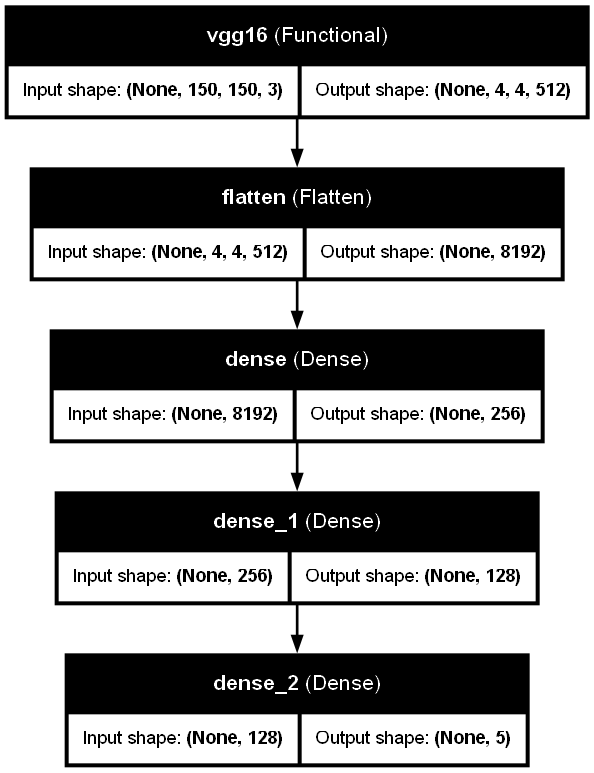

In [11]:
tf.keras.utils.plot_model(
    model,
    show_shapes=True,
    show_dtype=False,
    show_layer_names=True,
    rankdir='TB',
    expand_nested=False,
    dpi=96
)

## Restore Checkpoints

In [12]:
# Training Config
if os.path.exists(CHECKPOINTS):
    try:
        print(f"Checkpoint found : restore from {CHECKPOINTS}")
        _ = model.load_weights(CHECKPOINT, by_name=False)
    except Exception as e:
        print("Something went wrong !", e)
        pass
else:
    print("No checkpoint found !")

Checkpoint found : restore from checkpoints/best_model.keras
Something went wrong !


## Training

In [13]:
# Training Config
model.compile(
    loss=tf.keras.losses.CategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=LEARNING_RATE),
    metrics=["accuracy"]
)

In [14]:
# Checkpoint
callback_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=CHECKPOINTS,
    save_weights_only=False,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

# Tensorboard
callback_tensorboard = tf.keras.callbacks.TensorBoard(
    log_dir=TENSORBOARD,
    write_images=True
)

callbacks = [callback_checkpoint, callback_tensorboard]

os.makedirs(os.path.dirname(CHECKPOINTS), exist_ok=True)
os.makedirs(TENSORBOARD, exist_ok=True)

In [15]:
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks
)

D:\Workspace\portofolio\portofolio-flowers-classifier\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


Epoch 1/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6148 - loss: 1.0405
Epoch 1: val_accuracy improved from None to 0.70981, saving model to checkpoints/best_model.keras

Epoch 1: finished saving model to checkpoints/best_model.keras
46/46 ━━━━━━━━━━━━━━━━━━━━ 249s 5s/step - accuracy: 0.6148 - loss: 1.0405 - val_accuracy: 0.7098 - val_loss: 0.7949
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7772 - loss: 0.6646
Epoch 2: val_accuracy improved from 0.70981 to 0.73297, saving model to checkpoints/best_model.keras

Epoch 2: finished saving model to checkpoints/best_model.keras
46/46 ━━━━━━━━━━━━━━━━━━━━ 236s 5s/step - accuracy: 0.7772 - loss: 0.6646 - val_accuracy: 0.7330 - val_loss: 0.7095
Epoch 3/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8317 - loss: 0.5240
Epoch 3: val_accuracy improved from 0.73297 to 0.78747, saving model to checkpoints/best_model.keras

Epoch 3: finished saving model to checkpoints/best_model.keras
46/46 ━━━━━━━━━━━━━━━━━━━━ 

## Reporting

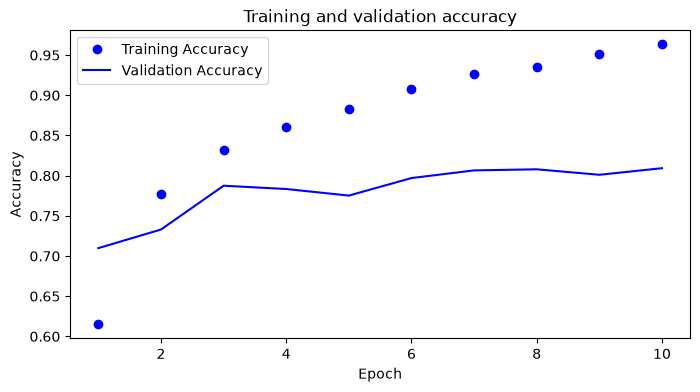

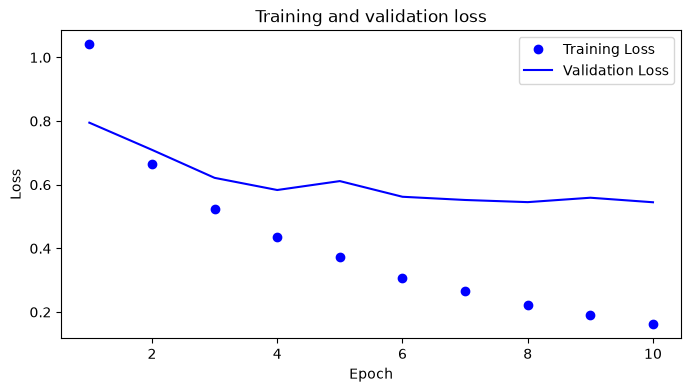

In [16]:
acc = history.history['accuracy']
loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs, acc, 'bo', label='Training Accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and validation accuracy')
plt.legend(loc='best')
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(epochs, loss, 'bo', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and validation loss')
plt.legend(loc='best')
plt.show()

## Evaluation

In [17]:
val_loss, val_accuracy = model.evaluate(val_ds)
print(f"Validation loss: {val_loss:.4f}")
print(f"Validation accuracy: {val_accuracy:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 77s 6s/step - accuracy: 0.8093 - loss: 0.5448
Validation loss: 0.5448
Validation accuracy: 0.8093


## Load best model

In [36]:
# Load best model
best_model = tf.keras.models.load_model(CHECKPOINTS)
best_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)                   │ (None, 4, 4, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       2,097,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 18,976,588 (72.39 MB)

 Trainable params: 2,130,949 (8.13 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 2,130,951 (8.13 MB)

## Prepare for Serving

In [40]:
# Define a Module wrapper that tracks the Keras model variables
class ServingModel(tf.keras.Model):
    def __init__(self, model, class_names):
        super().__init__()
        self.model = model
        self.class_names = tf.constant(class_names, dtype=tf.string)

    @tf.function(input_signature=[
        tf.TensorSpec(shape=[None, WIDTH, HEIGHT, NUM_CHANNELS], dtype=tf.float32, name="images")
    ])
    def call(self, images):
        # Forward pass (inference mode)
        probs = self.model(images, training=False)

        top_indices = tf.argmax(probs, axis=-1)
        top_classes = tf.gather(self.class_names, top_indices)
        confidences = tf.reduce_max(probs, axis=-1)

        # Build output dictionary matching the metadata schema
        outputs = {
            "classes": top_classes,
            "confidences": confidences,
        }
        for i, name in enumerate(class_names):
            outputs[name] = probs[:, i]

        return outputs

# Instantiate module
serving_model = ServingModel(best_model, class_names)

## Test model

In [45]:
dummy_input = tf.zeros((1, WIDTH, HEIGHT, NUM_CHANNELS), dtype=tf.float32)
dummy_output = serving_model(dummy_input)
pprint(dummy_output)

{'classes': <tf.Tensor: shape=(1,), dtype=string, numpy=array([b'dandelion'], dtype=object)>,
 'confidences': <tf.Tensor: shape=(1,), dtype=float32, numpy=array([0.54530907], dtype=float32)>,
 'daisy': <tf.Tensor: shape=(1,), dtype=float32, numpy=array([0.4285481], dtype=float32)>,
 'dandelion': <tf.Tensor: shape=(1,), dtype=float32, numpy=array([0.54530907], dtype=float32)>,
 'roses': <tf.Tensor: shape=(1,), dtype=float32, numpy=array([0.00632488], dtype=float32)>,
 'sunflowers': <tf.Tensor: shape=(1,), dtype=float32, numpy=array([0.00660784], dtype=float32)>,
 'tulips': <tf.Tensor: shape=(1,), dtype=float32, numpy=array([0.01321017], dtype=float32)>}


## Export model

In [46]:
# Create folder
os.makedirs(EXPORT_DIR, exist_ok=True)

# Save model in SavedModel format with TF Serving signature
serving_model.export(os.path.join(EXPORT_DIR, "4"))

INFO:tensorflow:Assets written to: models/flower_classifier\4\assets


INFO:tensorflow:Assets written to: models/flower_classifier\4\assets


Saved artifact at 'models/flower_classifier\4'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name=None)
Output Type:
  Dict[['classes', TensorSpec(shape=(None,), dtype=tf.string, name=None)], ['confidences', TensorSpec(shape=(None,), dtype=tf.float32, name=None)], ['daisy', TensorSpec(shape=(None,), dtype=tf.float32, name=None)], ['dandelion', TensorSpec(shape=(None,), dtype=tf.float32, name=None)], ['roses', TensorSpec(shape=(None,), dtype=tf.float32, name=None)], ['sunflowers', TensorSpec(shape=(None,), dtype=tf.float32, name=None)], ['tulips', TensorSpec(shape=(None,), dtype=tf.float32, name=None)]]
Captures:
  2390109371280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2390109363600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2390109366864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2390109370896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  23901093